# Reconstruction, error tails and example spectra

We examine the cost of prediction for the decoder. Errors of individual spectra and m/z regions are retained so that an average cannot hide deterioration in a subgroup.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_5_reconstruction_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:27:22,613 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:27:22,615 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:27:22,951 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:27:22,952 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:27:22,953 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:27:22,954 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Reconstruction distributions and the prediction trade-off

### Methodology

#### Theoretical

Masserstein is computed with the training implementation and saved parameters. Additional metrics are MSE, MAE, cosine similarity, spectral angle and TIC error; mean, median, q90 and q99 remain separate statistics.

#### Implementation

Evaluation concerns binned TIC-normalized X, not the raw signal before binning. Every pixel in the saved partition is evaluated. Conclusions about repetitions use the distribution of run summaries; pixel distributions describe sample heterogeneity.

#### Figure descriptions

First plot: x=head, y=per-spectrum Masserstein; the violin uses all values, while points are at most 200 evenly selected positions in table order. Second plot: x=mean validation Masserstein, y=validation AP; a point is a run. Lower cost and higher AP are favourable.


,metric,statistic,value,pixels,split,model_id,label,condition,repetition
0,mse,mean,1.120166e-05,33650,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
1,mse,median,9.334006e-06,33650,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
2,mse,q90,2.386594e-05,33650,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
3,mse,q99,5.086145e-05,33650,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
4,mae,mean,9.641197e-04,33650,train,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
...,...,...,...,...,...,...,...,...,...
4675,tic_error,q99,2.384186e-07,4205,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
4676,masserstein,mean,3.495834e+00,4205,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
4677,masserstein,median,2.824979e+00,4205,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
4678,masserstein,q90,6.031995e+00,4205,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4


2026-09-08 10:28:00,552 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 4 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_5_reconstruction_results.


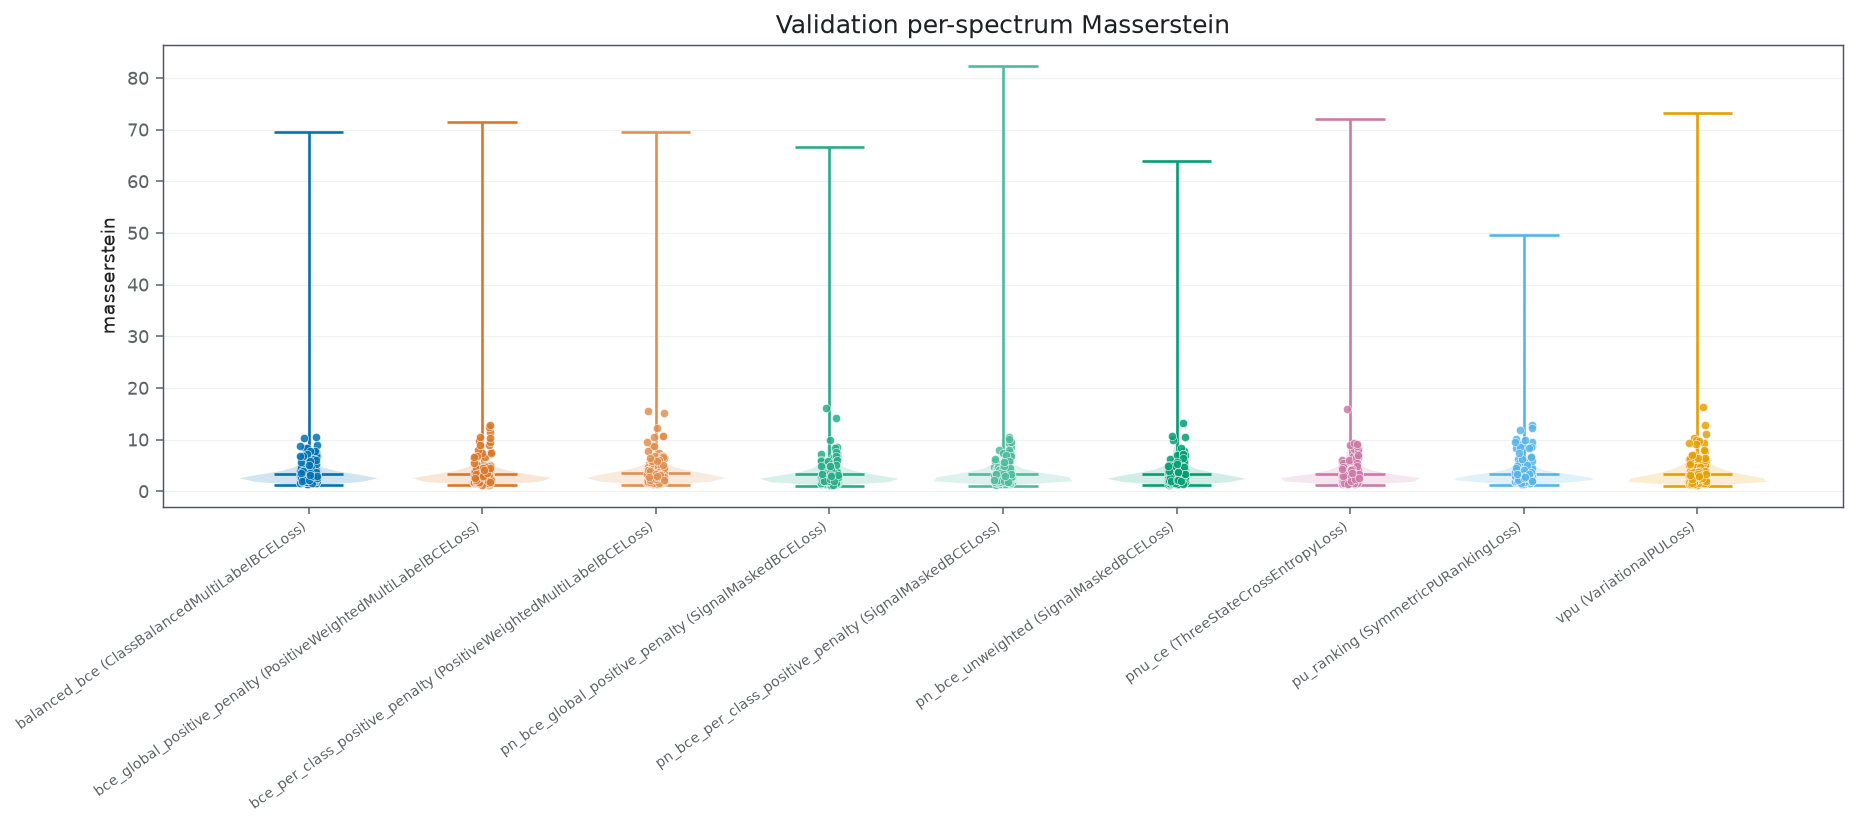

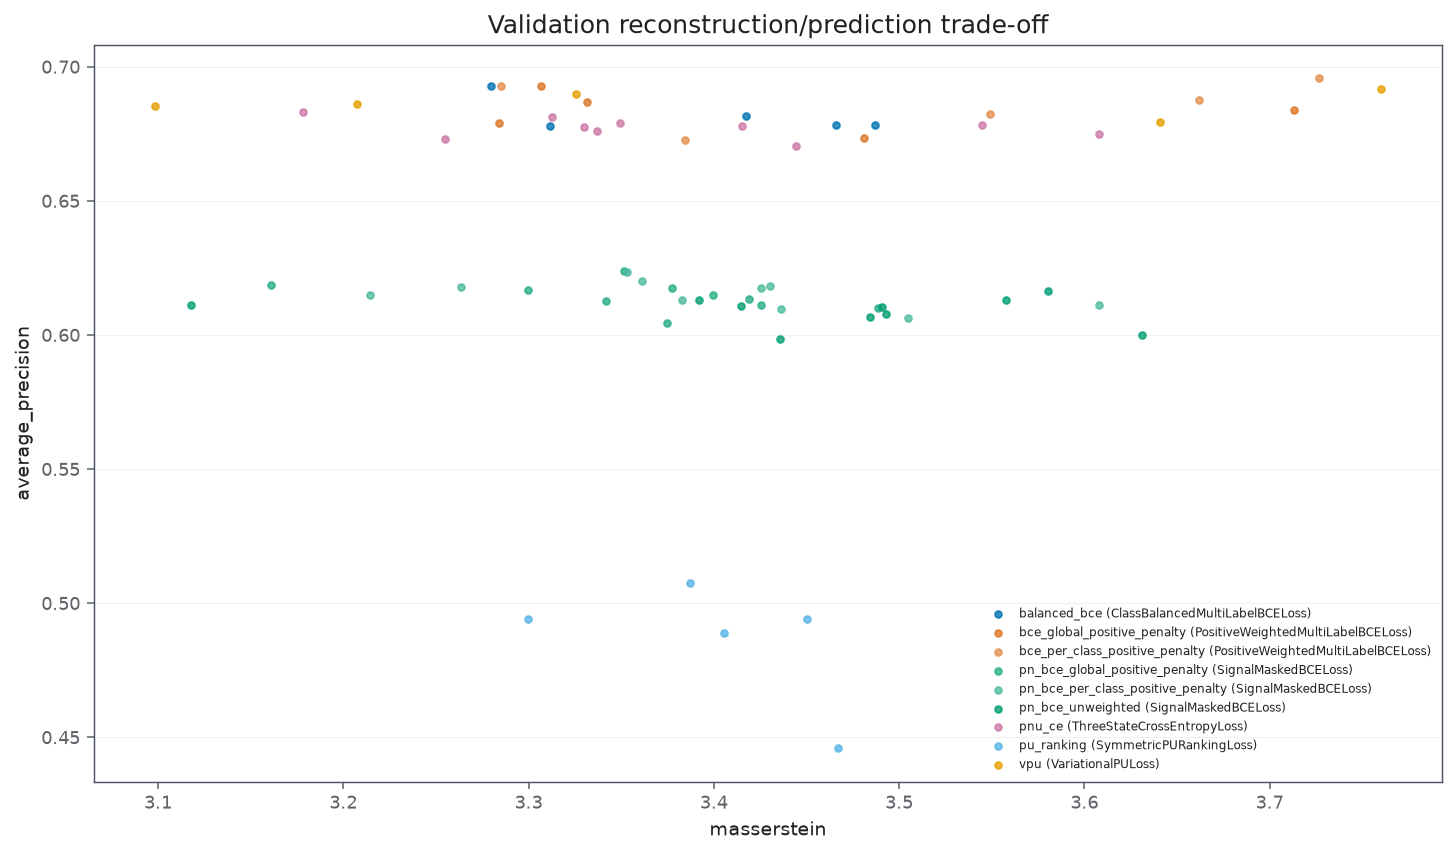

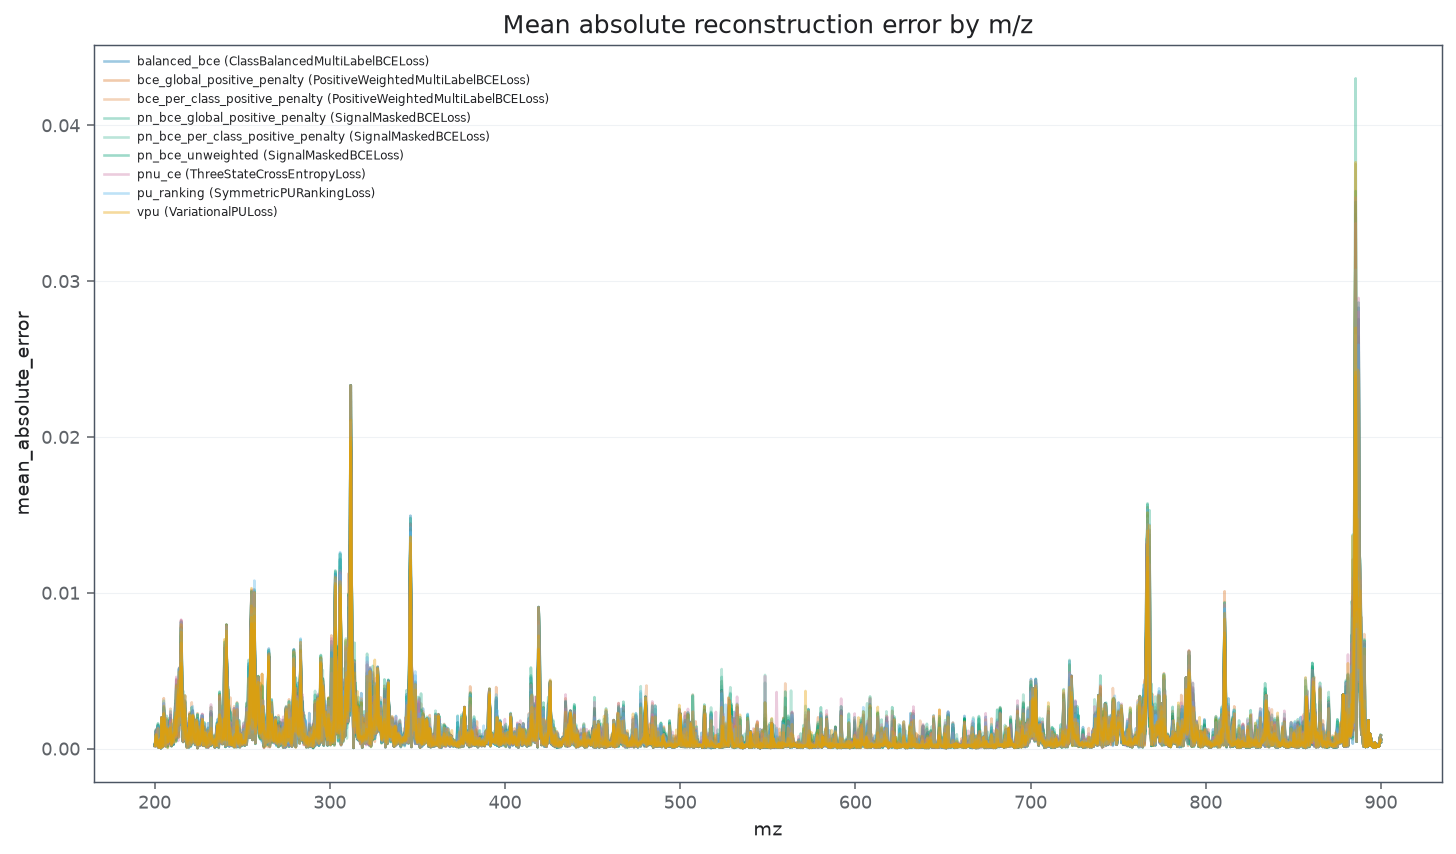

In [2]:
reconstruction = cache.load_table(settings, "reconstruction")
pixels = cache.load_table(settings, "reconstruction_pixels")
features = cache.load_table(settings, "reconstruction_features")
display(reconstruction)
plots.distributions(pixels.query("split == 'validation'"), value="masserstein", title="Validation per-spectrum Masserstein").savefig(RESULTS / "pixel_errors.png")
prediction = cache.load_table(settings, "prediction")
quality = prediction.query("split == 'validation' and scope == 'train_supported' and population == 'annotation_retrieval' and metric == 'average_precision'")[["model_id", "value"]].rename(columns={"value": "average_precision"})
tradeoff = reconstruction.query("split == 'validation' and metric == 'masserstein' and statistic == 'mean'").merge(quality, on="model_id", validate="one_to_one").rename(columns={"value": "masserstein"})
plots.scatter(tradeoff, x="masserstein", y="average_precision", title="Validation reconstruction/prediction trade-off").savefig(RESULTS / "tradeoff.png")
plots.trajectories(features.query("split == 'validation'"), x="mz", y="mean_absolute_error", title="Mean absolute reconstruction error by m/z").savefig(RESULTS / "feature_errors.png")
reports.save_tables(RESULTS, reconstruction=reconstruction, pixels=pixels, features=features, tradeoff=tradeoff)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Examples and dependence on spectrum properties

### Methodology

#### Theoretical

Comparing the same spectra helps distinguish peak broadening, signal loss and shifts. Worst examples are selected by the cost of the given model and do not represent a random sample.

#### Implementation

The cache retains three fixed shared positions from the geometry sample and the three worst spectra of each run. Error tables for all pixels allow examination of dependence on annotation count, input maximum and the number of nonzero bins.

#### Figure descriptions

Spectrum panel: x=m/z, y=TIC intensity; grey line=input, second line=reconstruction. The title gives row_position and the flag identifying selection among the worst cases. Dependence plot: x=number of nonzero bins, y=Masserstein; a point is a spectrum.


2026-09-08 10:28:14,536 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_5_reconstruction_results.


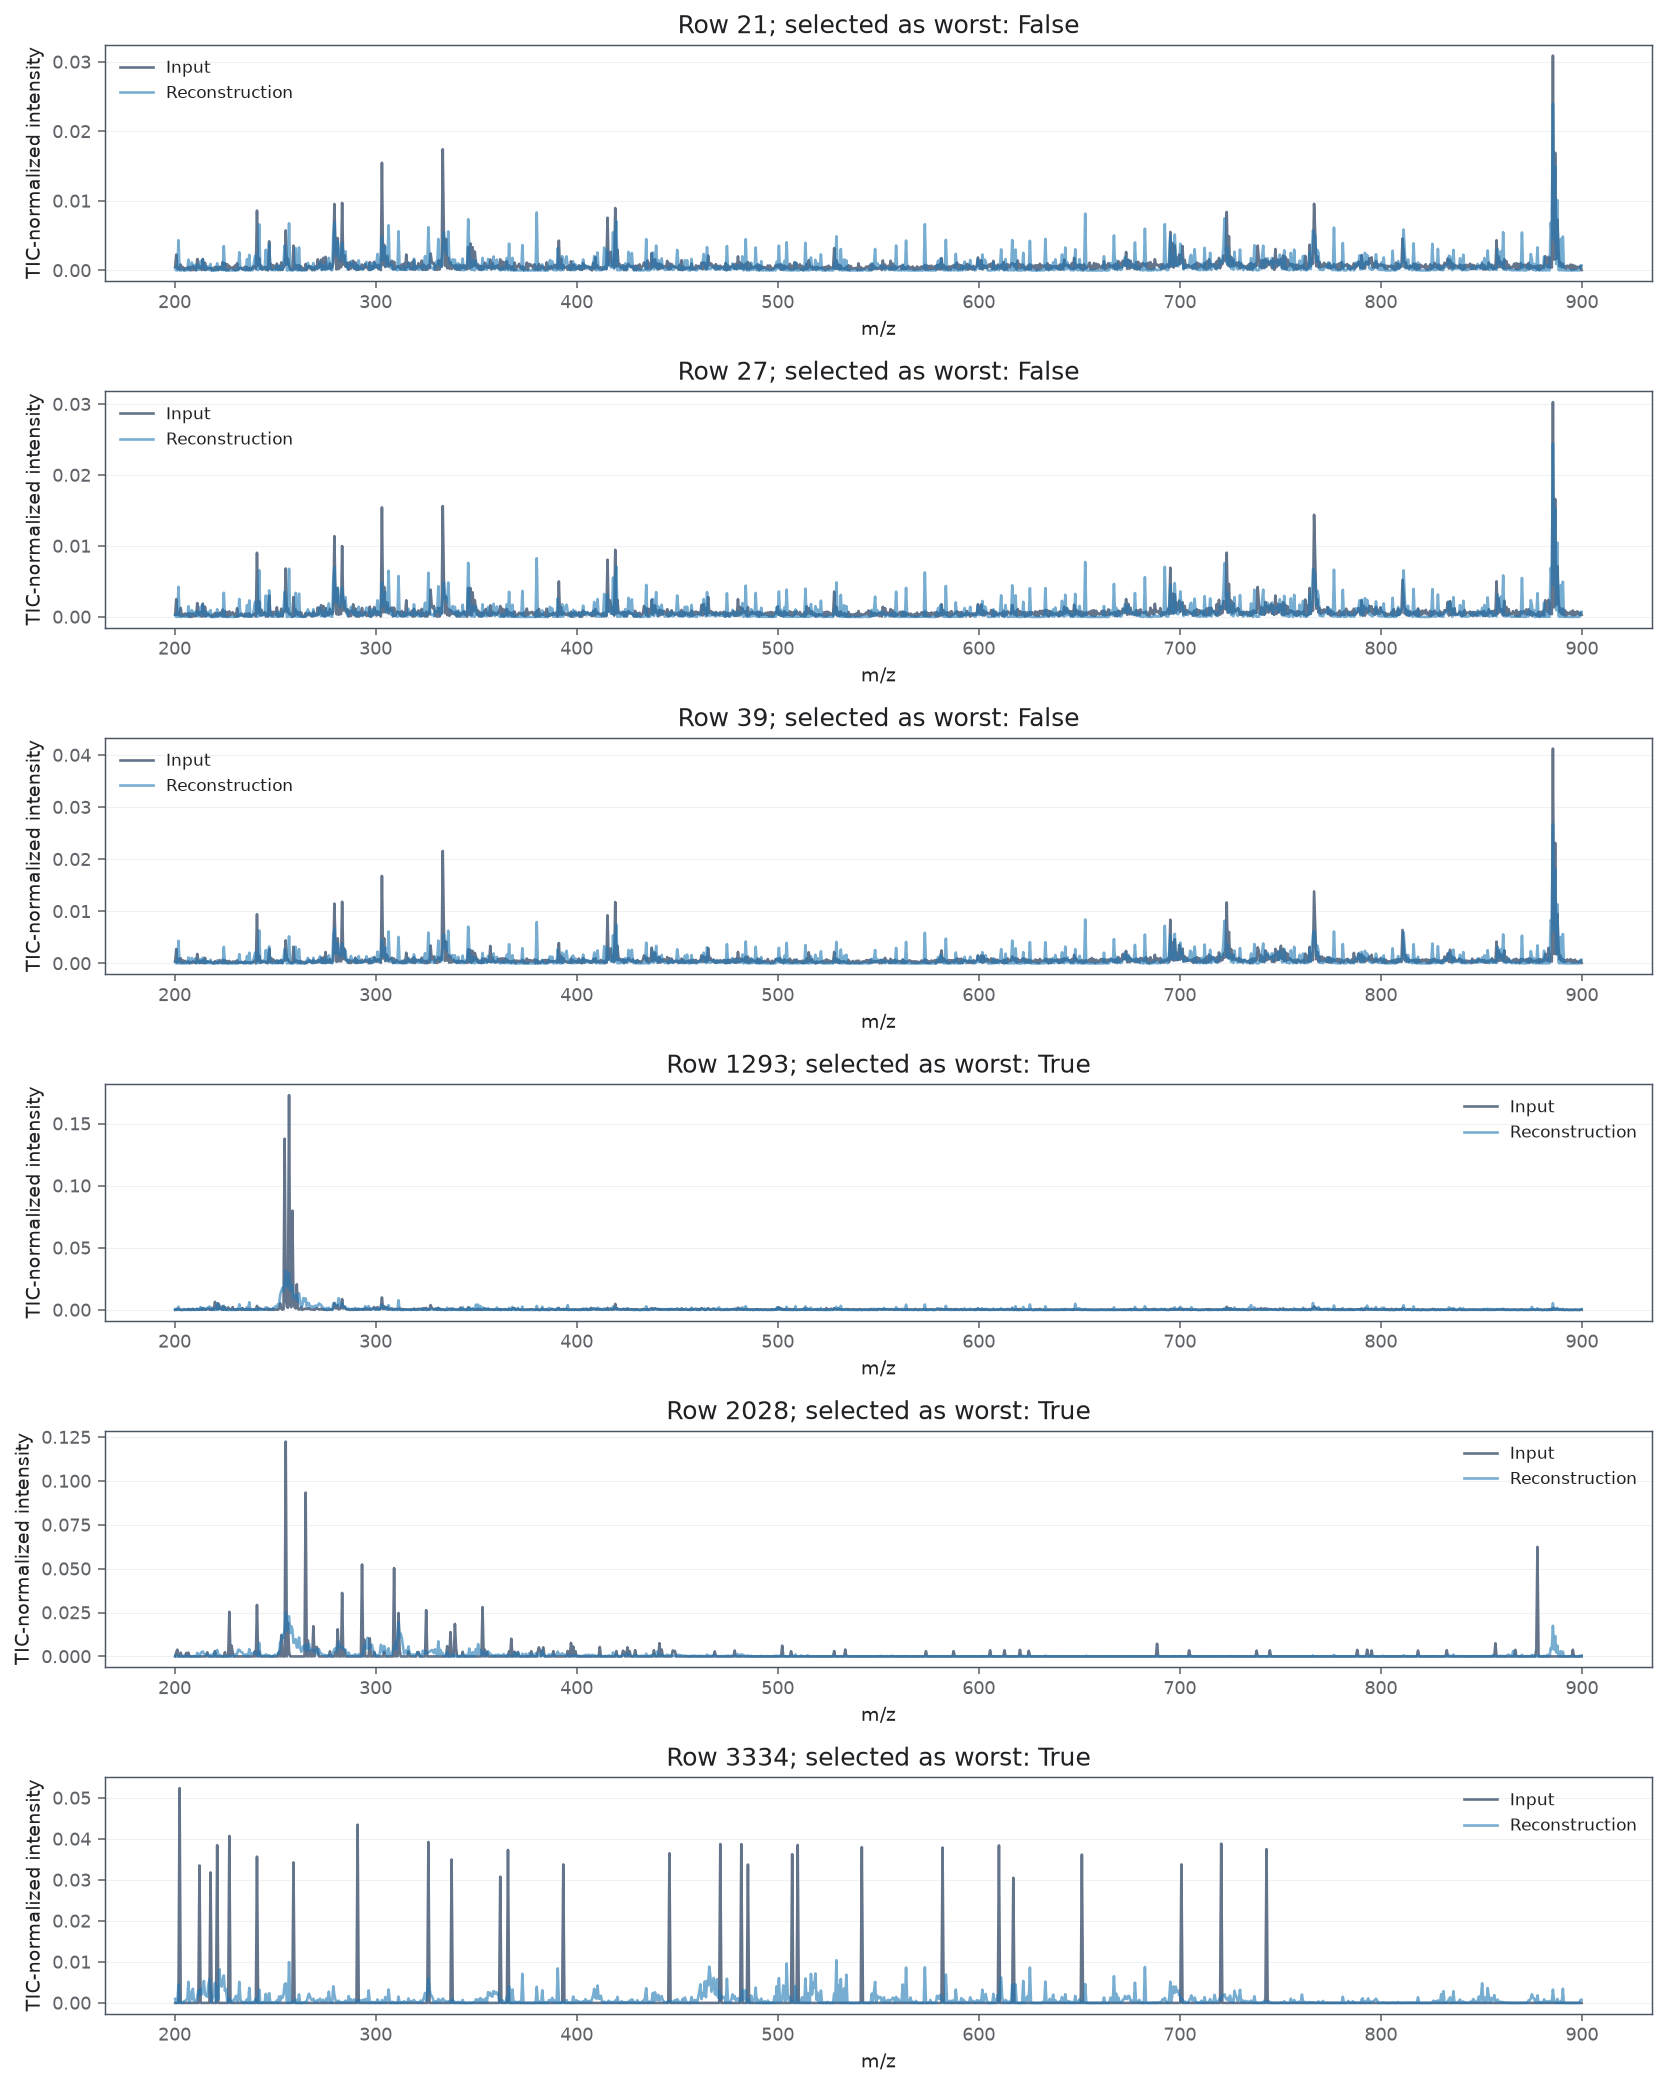

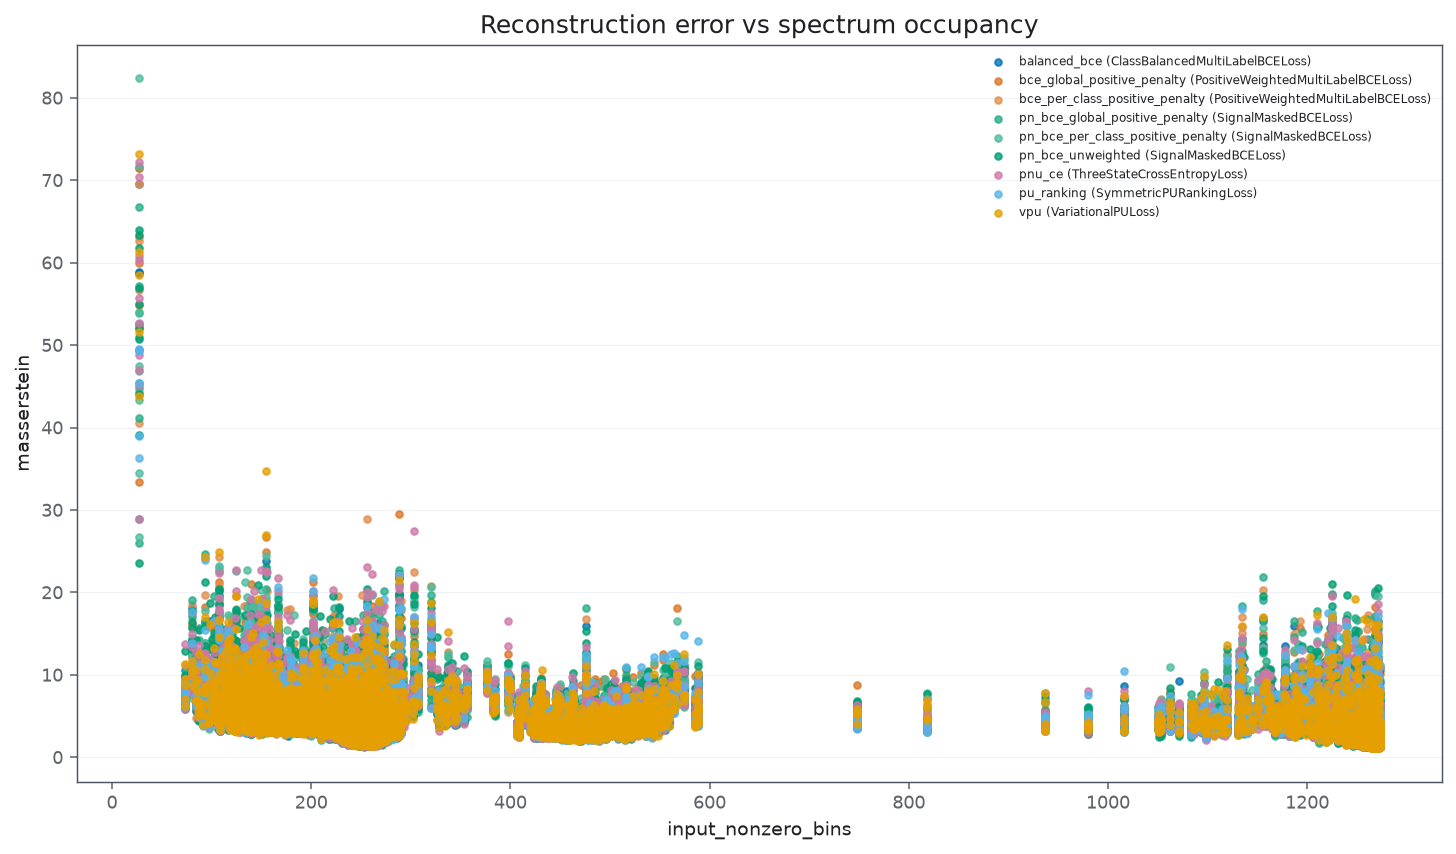

In [3]:
cases = cache.load_table(settings, "spectrum_cases")
example_model = sorted(cases.model_id.unique())[0]
plots.spectrum_cases(cases.query("model_id == @example_model and split == 'validation'")).savefig(RESULTS / "example_spectra.png")
plots.scatter(pixels.query("split == 'validation'"), x="input_nonzero_bins", y="masserstein", title="Reconstruction error vs spectrum occupancy").savefig(RESULTS / "error_vs_occupancy.png")
reports.save_tables(RESULTS, spectrum_cases=cases)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
